# Task 1 : Data Preprocessing and Dataset Preparation

Importing necessary libraries

In [ ]:
import re
import nltk
import pandas as pd
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

Downloading wordnet, stopwords etc

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
with open('Corpus.txt','r') as f:             # Reading the Corpus text file
  corpus = f.read()

Text Pre-processing and Tokenization

In [ ]:
corpus = corpus.lower()                      # Lowercasing the text in corpus
corpus = re.sub(r'[^a-zA-Z0-9\s]', '', corpus) # removal of Punctuation marks

tokens = word_tokenize(corpus)                  # Tokenization
stop_words = set(stopwords.words('english'))    # Stop words removal

filtered_tokens = [word for word in tokens if word not in stop_words] # Filtered tokens after stop word removal

Lemmatization technique to convert the words into their root forms

In [ ]:
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]
print(f"Original tokens (first 20): {filtered_tokens[:20]}")
print(f"Lemmatized tokens (first 20): {lemmatized_tokens[:20]}")

Original tokens (first 20): ['academic', 'programmes', 'indian', 'institute', 'technology', 'jodhpur', 'designed', 'develop', 'highest', 'calibre', 'human', 'resource', 'capable', 'understanding', 'new', 'patterns', 'knowledge', 'creation', 'across', 'disciplines']
Lemmatized tokens (first 20): ['academic', 'programme', 'indian', 'institute', 'technology', 'jodhpur', 'designed', 'develop', 'highest', 'calibre', 'human', 'resource', 'capable', 'understanding', 'new', 'pattern', 'knowledge', 'creation', 'across', 'discipline']


In [ ]:
total_tokens = len(lemmatized_tokens)
unique_tokens = len(set(lemmatized_tokens))

print(f"Total tokens: {total_tokens}")
print(f"Unique tokens: {unique_tokens}")

vocabulary = set(lemmatized_tokens)
print(f"Vocabulary size: {len(vocabulary)}")

Total tokens: 2724
Unique tokens: 1028
Vocabulary size: 1028


Forming the word cloud based on frequency of each word's appearance in the corpus

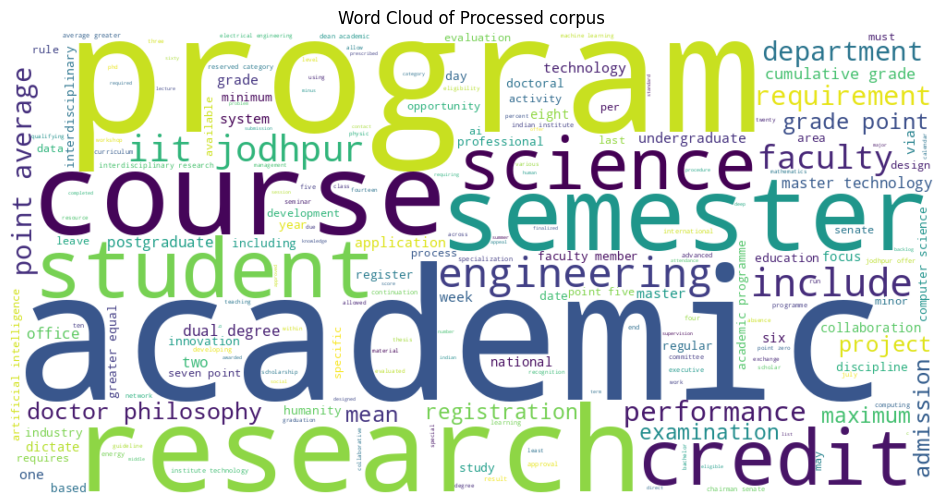

In [ ]:
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(' '.join(lemmatized_tokens))
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Processed corpus')
plt.show()

# Task 2 and 3(1): Model Training

In [ ]:
cleaned_tokens = [token for token in lemmatized_tokens if not token.isdigit() and len(token) > 1]
word2vec_input = [cleaned_tokens]

print(f"First 20 cleaned tokens: {cleaned_tokens[:20]}")
print(f"Length of word2vec_input: {len(word2vec_input)}")

First 20 cleaned tokens: ['academic', 'programme', 'indian', 'institute', 'technology', 'jodhpur', 'designed', 'develop', 'highest', 'calibre', 'human', 'resource', 'capable', 'understanding', 'new', 'pattern', 'knowledge', 'creation', 'across', 'discipline']
Length of word2vec_input: 1


In [ ]:
vocabulary = sorted(list(set(cleaned_tokens)))
word_to_idx = {word: i for i, word in enumerate(vocabulary)}
idx_to_word = {i: word for i, word in enumerate(vocabulary)}

vocabulary_size = len(vocabulary)
print(f"Vocabulary size: {vocabulary_size}")
print(f"First 10 word_to_idx entries: {list(word_to_idx.items())[:10]}")

window_size = 2
print(f"Context window size: {window_size}")

cbow_pairs = []
skipgram_pairs = []

for i, word in enumerate(cleaned_tokens):
    target_idx = word_to_idx[word]
    context_words = []
    for j in range(max(0, i - window_size), min(len(cleaned_tokens), i + window_size + 1)):
        if i == j: # Skip the target word itself
            continue
        context_word = cleaned_tokens[j]
        context_idx = word_to_idx[context_word]
        context_words.append(context_idx)

        # For Skip-gram, each context word creates a pair with the target
        skipgram_pairs.append((target_idx, context_idx))

    # For CBOW, combine all context words for the target
    if context_words:
        cbow_pairs.append((context_words, target_idx))

print(f"Number of CBOW training pairs: {len(cbow_pairs)}")
print(f"First 5 CBOW pairs: {cbow_pairs[:5]}")
print(f"Number of Skip-gram training pairs: {len(skipgram_pairs)}")
print(f"First 5 Skip-gram pairs: {skipgram_pairs[:5]}")

Vocabulary size: 1019
First 10 word_to_idx entries: [('ability', 0), ('able', 1), ('abroad', 2), ('absence', 3), ('academia', 4), ('academic', 5), ('academically', 6), ('accelerator', 7), ('access', 8), ('accurate', 9)]
Context window size: 2
Number of CBOW training pairs: 2708
First 5 CBOW pairs: [([724, 482], 5), ([5, 482, 493], 724), ([5, 724, 493, 913], 482), ([724, 482, 913, 516], 493), ([482, 493, 516, 250], 913)]
Number of Skip-gram training pairs: 10826
First 5 Skip-gram pairs: [(5, 724), (5, 482), (724, 5), (724, 482), (724, 493)]


In [ ]:
def one_hot_encode(word_idx, vocabulary_size):
    one_hot_vector = np.zeros(vocabulary_size)
    one_hot_vector[word_idx] = 1
    return one_hot_vector

print("One-hot encoding function 'one_hot_encode' defined.")

One-hot encoding function 'one_hot_encode' defined.


In [ ]:
embedding_dimensions = [50, 100]
context_window_sizes = [5, 8]
num_negative_samples = [5, 10]

print(f"Embedding Dimensions: {embedding_dimensions}")
print(f"Context Window Sizes: {context_window_sizes}")
print(f"Number of Negative Samples: {num_negative_samples}")

Embedding Dimensions: [50, 100]
Context Window Sizes: [5, 8]
Number of Negative Samples: [5, 10]


## Implementing CBOW Model from Scratch



In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

print("Sigmoid activation function defined.")

Sigmoid activation function defined.


In [ ]:
def generate_negative_samples(target_idx, vocabulary_size, num_samples):
    negative_samples = []
    while len(negative_samples) < num_samples:
        rand_idx = np.random.randint(0, vocabulary_size)
        if rand_idx != target_idx and rand_idx not in negative_samples:
            negative_samples.append(rand_idx)
    return negative_samples

print("Negative sampling function 'generate_negative_samples' defined.")

Negative sampling function 'generate_negative_samples' defined.


In [ ]:
class CBOWModel:
    def __init__(self, vocabulary_size, embedding_dim, learning_rate):
        self.vocabulary_size = vocabulary_size
        self.embedding_dim = embedding_dim
        self.learning_rate = learning_rate

        # Initialize input weight matrix W_in and scale by 1/sqrt(embedding_dim) to maintain variance
        self.W_in = np.random.uniform(-1, 1, (vocabulary_size, embedding_dim)) / np.sqrt(embedding_dim)

        # Initialize output weight matrix W_out
        self.W_out = np.random.uniform(-1, 1, (embedding_dim, vocabulary_size)) / np.sqrt(vocabulary_size)

        print(f"CBOWModel initialized with vocabulary_size={vocabulary_size}, embedding_dim={embedding_dim}, learning_rate={learning_rate}")
        print(f"W_in shape: {self.W_in.shape}")
        print(f"W_out shape: {self.W_out.shape}")

    def train_step(self, context_word_indices, target_word_index, num_negative_samples):
        # Forward Pass: Get context embeddings and average them
        context_embeddings = np.array([self.W_in[idx] for idx in context_word_indices])
        h = np.mean(context_embeddings, axis=0)

        # Negative Sampling
        negative_samples_indices = generate_negative_samples(target_word_index, self.vocabulary_size, num_negative_samples)
        sample_indices = [target_word_index] + negative_samples_indices
        labels = [1] + [0] * num_negative_samples

        # Loss Calculation and Backpropagation
        total_loss = 0
        grad_W_in = np.zeros_like(self.W_in)
        grad_W_out = np.zeros_like(self.W_out)
        dL_dh = np.zeros_like(h)

        for current_label, current_idx in zip(labels, sample_indices):
            score = np.dot(h, self.W_out[:, current_idx])
            prediction = sigmoid(score)
            error = prediction - current_label

            # Add a small epsilon to avoid log(0) for loss calculation
            total_loss += - (current_label * np.log(prediction + 1e-10) + (1 - current_label) * np.log(1 - prediction + 1e-10))

            # Update gradients
            grad_W_out[:, current_idx] += error * h
            dL_dh += error * self.W_out[:, current_idx]

        # Update grad_W_in for the context words
        if len(context_word_indices) > 0:                                 # Avoid division by zero if no context words
            for c_idx in context_word_indices:
                grad_W_in[c_idx, :] += dL_dh / len(context_word_indices)  # Since h is an average, the gradient is distributed among the context words

        # Apply updates to weights
        self.W_in -= self.learning_rate * grad_W_in
        self.W_out -= self.learning_rate * grad_W_out

        return total_loss

    def get_word_embedding(self, word, word_to_idx):
        if word in word_to_idx:
            return self.W_in[word_to_idx[word]]
        else:
            return None                                                    # Or raise an error, or return a zero vector

print("CBOWModel class structure (including train_step and get_word_embedding) defined.")


CBOWModel class structure (including train_step and get_word_embedding) defined.


## Train and Evaluate CBOW Models


In [ ]:
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    similarity = dot_product / (norm_vec1 * norm_vec2 + 1e-10) # Add epsilon to avoid division by zero
    return similarity

print("Cosine similarity function 'cosine_similarity' defined.")

Cosine similarity function 'cosine_similarity' defined.


In [ ]:
def find_most_similar_words(word, model_W_in, word_to_idx, idx_to_word, top_n=5):
    if word not in word_to_idx:
        return []
    word_embedding = model_W_in[word_to_idx[word]]

    similarities = []
    for i, w in idx_to_word.items():
        if w == word:
            continue
        sim = cosine_similarity(word_embedding, model_W_in[i])
        similarities.append((w, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

print("Function 'find_most_similar_words' defined.")

Function 'find_most_similar_words' defined.


In [ ]:
def train_cbow_model(cbow_pairs, vocabulary_size, word_to_idx, idx_to_word, embedding_dim, learning_rate, num_epochs, num_negative_samples):
    print(f"\n--- Training CBOW Model (Embedding Dim: {embedding_dim}, Learning Rate: {learning_rate}, Epochs: {num_epochs}, Negative Samples: {num_negative_samples}) ---")
    model = CBOWModel(vocabulary_size, embedding_dim, learning_rate)

    for epoch in range(num_epochs):
        total_loss = 0
        np.random.shuffle(cbow_pairs)                                           # Shuffle cbow_pairs for better training
        for context_indices, target_idx in cbow_pairs:
            if not context_indices:                                             # Skip if no context words available
                continue
            loss = model.train_step(context_indices, target_idx, num_negative_samples)
            total_loss += loss

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(cbow_pairs):.4f}")

    print("Training complete. Evaluating embeddings...")

    common_words = ['research', 'student', 'phd','exam']                        # Evaluating by showing similar words (Task 3 part 1)
    for word in common_words:
        similar_words = find_most_similar_words(word, model.W_in, word_to_idx, idx_to_word)
        if similar_words:
            print(f"Words similar to '{word}': {', '.join([f'{w} ({s:.2f})' for w, s in similar_words])}")
        else:
            print(f"'{word}' not found in vocabulary or no similar words found.")

    return model.W_in

print("Function 'train_cbow_model' defined.")

Function 'train_cbow_model' defined.


In [ ]:
cbow_results = {}

for ed in embedding_dimensions:
    for cws in context_window_sizes:
        current_cbow_pairs = []
        for i, word in enumerate(cleaned_tokens):     # Regenerate CBOW pairs for the current context window size
            target_idx = word_to_idx[word]
            context_words_for_pair = []
            start = max(0, i - cws)                    # Defining start for context window, ensuring it stays within bounds
            end = min(len(cleaned_tokens), i + cws + 1) # Defining end for context window, ensuring it stays within bounds

            for j in range(start, end):
                if i == j:                              # Skip the target word itself
                    continue
                context_word = cleaned_tokens[j]
                context_idx = word_to_idx[context_word]
                context_words_for_pair.append(context_idx)
            if context_words_for_pair:
                current_cbow_pairs.append((context_words_for_pair, target_idx))

        for nns in num_negative_samples:
            key = (ed, cws, nns)
            print(f"\n--- Training CBOW Model with Hyperparameters: Embedding Dim={ed}, Context Window Size={cws}, Negative Samples={nns} ---")
            trained_W_in = train_cbow_model(current_cbow_pairs, vocabulary_size, word_to_idx, idx_to_word, embedding_dim=ed, learning_rate=0.01, num_epochs=10, num_negative_samples=nns)
            cbow_results[key] = trained_W_in
            print(f"CBOW model trained for (Embedding Dim: {ed}, Context Window Size: {cws}, Negative Samples: {nns}).")

print("\nAll CBOW models trained and evaluated. Stored results in 'cbow_results'.")



--- Training CBOW Model with Hyperparameters: Embedding Dim=50, Context Window Size=5, Negative Samples=5 ---

--- Training CBOW Model (Embedding Dim: 50, Learning Rate: 0.01, Epochs: 10, Negative Samples: 5) ---
CBOWModel initialized with vocabulary_size=1019, embedding_dim=50, learning_rate=0.01
W_in shape: (1019, 50)
W_out shape: (50, 1019)
Epoch 1/10, Loss: 4.1587
Epoch 2/10, Loss: 4.1584
Epoch 3/10, Loss: 4.1580
Epoch 4/10, Loss: 4.1577
Epoch 5/10, Loss: 4.1572
Epoch 6/10, Loss: 4.1569
Epoch 7/10, Loss: 4.1565
Epoch 8/10, Loss: 4.1555
Epoch 9/10, Loss: 4.1551
Epoch 10/10, Loss: 4.1541
Training complete. Evaluating embeddings...
Words similar to 'research': enable (0.49), scientific (0.40), application (0.39), becoming (0.39), obc (0.37)
Words similar to 'student': dependent (0.46), mdes (0.44), adult (0.44), integrity (0.42), device (0.34)
Words similar to 'phd': extracurricular (0.41), eighth (0.40), objective (0.40), saving (0.36), sulfide (0.34)
Words similar to 'exam': art (0

In [ ]:
class SkipgramModel:
    def __init__(self, vocabulary_size, embedding_dim, learning_rate):
        self.vocabulary_size = vocabulary_size
        self.embedding_dim = embedding_dim
        self.learning_rate = learning_rate

        # Initialize input weight matrix W_in (word embeddings) and scale by 1/sqrt(embedding_dim) to maintain variance
        self.W_in = np.random.uniform(-1, 1, (vocabulary_size, embedding_dim)) / np.sqrt(embedding_dim)

        # Initialize output weight matrix W_out (context word weights)
        self.W_out = np.random.uniform(-1, 1, (embedding_dim, vocabulary_size)) / np.sqrt(vocabulary_size)

        print(f"SkipgramModel initialized with vocabulary_size={vocabulary_size}, embedding_dim={embedding_dim}, learning_rate={learning_rate}")
        print(f"W_in shape: {self.W_in.shape}")
        print(f"W_out shape: {self.W_out.shape}")

    def train_step(self, target_word_index, context_word_index, num_negative_samples):
        # Forward Pass: Get target word embedding
        v_t = self.W_in[target_word_index]            # v_t is the embedding for the target word

        # Negative Sampling
        negative_samples_indices = generate_negative_samples(context_word_index, self.vocabulary_size, num_negative_samples)
        sample_indices = [context_word_index] + negative_samples_indices
        labels = [1] + [0] * num_negative_samples

        # Loss Calculation and Backpropagation
        total_loss = 0
        grad_W_in = np.zeros_like(self.W_in)
        grad_W_out = np.zeros_like(self.W_out)

        # Gradient for target word embedding (v_t) will accumulate here
        dL_dv_t = np.zeros_like(v_t)

        for current_label, current_idx in zip(labels, sample_indices):
            u_c = self.W_out[:, current_idx]         # u_c is the output context vector for current_idx
            score = np.dot(v_t, u_c)
            prediction = sigmoid(score)
            error = prediction - current_label

            # Add a small epsilon to avoid log(0) for loss calculation
            total_loss += - (current_label * np.log(prediction + 1e-10) + (1 - current_label) * np.log(1 - prediction + 1e-10))

            # Update gradients for W_out
            grad_W_out[:, current_idx] += error * v_t

            # Accumulate gradient for v_t
            dL_dv_t += error * u_c

        # Apply updates to W_in for the target word
        grad_W_in[target_word_index, :] = dL_dv_t

        # Apply updates to weights
        self.W_in -= self.learning_rate * grad_W_in
        self.W_out -= self.learning_rate * grad_W_out

        return total_loss

    def get_word_embedding(self, word, word_to_idx):
        if word in word_to_idx:
            return self.W_in[word_to_idx[word]]
        else:
            return None                             # Or raise an error, or return a zero vector

print("SkipgramModel class structure (including train_step and get_word_embedding) defined.")

SkipgramModel class structure (including train_step and get_word_embedding) defined.


In [ ]:
def train_skipgram_model(skipgram_pairs, vocabulary_size, word_to_idx, idx_to_word, embedding_dim, learning_rate, num_epochs, num_negative_samples):
    print(f"\n--- Training Skip-gram Model (Embedding Dim: {embedding_dim}, Learning Rate: {learning_rate}, Epochs: {num_epochs}, Negative Samples: {num_negative_samples}) ---")
    model = SkipgramModel(vocabulary_size, embedding_dim, learning_rate)

    for epoch in range(num_epochs):
        total_loss = 0
        np.random.shuffle(skipgram_pairs)         # Shuffle skipgram_pairs for better training
        for target_idx, context_idx in skipgram_pairs:
            loss = model.train_step(target_idx, context_idx, num_negative_samples)
            total_loss += loss
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(skipgram_pairs):.4f}")

    print("Training complete. Evaluating embeddings...")

    common_words = common_words = ['research', 'student', 'phd','exam']   # Evaluate by showing similar words
    for word in common_words:
        similar_words = find_most_similar_words(word, model.W_in, word_to_idx, idx_to_word)
        if similar_words:
            print(f"Words similar to '{word}': {', '.join([f'{w} ({s:.2f})' for w, s in similar_words])}")
        else:
            print(f"'{word}' not found in vocabulary or no similar words found.")

    return model.W_in

print("Function 'train_skipgram_model' defined.")

skipgram_results = {}

for ed in embedding_dimensions:
    for cws in context_window_sizes:
        current_skipgram_pairs = []
        for i, word in enumerate(cleaned_tokens):  # Regenerate Skip-gram pairs for the current context window size
            target_idx = word_to_idx[word]
            start = max(0, i - cws)
            end = min(len(cleaned_tokens), i + cws + 1)

            for j in range(start, end):
                if i == j:                        # Skip the target word itself
                    continue
                context_word = cleaned_tokens[j]
                context_idx = word_to_idx[context_word]
                current_skipgram_pairs.append((target_idx, context_idx))

        for nns in num_negative_samples:
            key = (ed, cws, nns)
            print(f"\n--- Training Skip-gram Model with Hyperparameters: Embedding Dim={ed}, Context Window Size={cws}, Negative Samples={nns} ---")
            trained_W_in_skipgram = train_skipgram_model(current_skipgram_pairs, vocabulary_size, word_to_idx, idx_to_word, embedding_dim=ed, learning_rate=0.01, num_epochs=10, num_negative_samples=nns)
            skipgram_results[key] = trained_W_in_skipgram
            print(f"Skip-gram model trained for (Embedding Dim: {ed}, Context Window Size: {cws}, Negative Samples: {nns}).")

print("\nAll Skip-gram models trained and evaluated. Stored results in 'skipgram_results'.")

Function 'train_skipgram_model' defined.

--- Training Skip-gram Model with Hyperparameters: Embedding Dim=50, Context Window Size=5, Negative Samples=5 ---

--- Training Skip-gram Model (Embedding Dim: 50, Learning Rate: 0.01, Epochs: 10, Negative Samples: 5) ---
SkipgramModel initialized with vocabulary_size=1019, embedding_dim=50, learning_rate=0.01
W_in shape: (1019, 50)
W_out shape: (50, 1019)
Epoch 1/10, Loss: 4.1573
Epoch 2/10, Loss: 4.1435
Epoch 3/10, Loss: 4.0447
Epoch 4/10, Loss: 3.6638
Epoch 5/10, Loss: 3.1615
Epoch 6/10, Loss: 2.7973
Epoch 7/10, Loss: 2.5690
Epoch 8/10, Loss: 2.4182
Epoch 9/10, Loss: 2.3126
Epoch 10/10, Loss: 2.2323
Training complete. Evaluating embeddings...
Words similar to 'research': interdisciplinary (0.85), program (0.81), area (0.80), faculty (0.79), education (0.78)
Words similar to 'student': registration (0.88), date (0.87), must (0.87), fifty (0.87), instructor (0.86)
Words similar to 'phd': offering (0.93), postgraduate (0.93), curriculum (0.93)

## Task 3 part 2

In [ ]:
def solve_analogy(word_a, word_b, word_c, model_W_in, word_to_idx, idx_to_word, top_n=1):
    if not all(word in word_to_idx for word in [word_a, word_b, word_c]):
        missing_words = [word for word in [word_a, word_b, word_c] if word not in word_to_idx]  # Return a list of missing words if any are not in the vocabulary
        print(f"Warning: One or more words not found in vocabulary: {missing_words}")
        return []

    # Get embeddings for A, B, C
    emb_a = model_W_in[word_to_idx[word_a]]
    emb_b = model_W_in[word_to_idx[word_b]]
    emb_c = model_W_in[word_to_idx[word_c]]

    # Calculate embedding for D (B - A + C)
    emb_d_candidate = emb_b - emb_a + emb_c

    similarities = []
    for i, word in idx_to_word.items():
        if word in [word_a, word_b, word_c]: # Exclude input words from results
            continue
        current_emb = model_W_in[i]
        sim = cosine_similarity(emb_d_candidate, current_emb)
        similarities.append((word, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

print("Analogy solving function 'solve_analogy' defined.")

Analogy solving function 'solve_analogy' defined.


In [ ]:
print("\n--- Analogy Experiments (CBOW Model) ---")

# Selecting a trained CBOW model for analogy experiments (ed=100, cws=5, nns=10)
selected_cbow_key = (100, 5, 10)
cbow_W_in_analogy = cbow_results.get(selected_cbow_key)

if cbow_W_in_analogy is None:
    print(f"Error: CBOW model for {selected_cbow_key} not found. Please check 'cbow_results' keys.")
else:
    print(f"Selected CBOW model with hyperparameters: {selected_cbow_key}")

    # Analogy 1: Engineering : Computer :: Science : ?
    word_a1, word_b1, word_c1 = 'engineering', 'computer', 'science'
    result1_cbow = solve_analogy(word_a1, word_b1, word_c1, cbow_W_in_analogy, word_to_idx, idx_to_word)
    if result1_cbow:
        print(f"{word_b1} - {word_a1} + {word_c1} = {result1_cbow[0][0]} (Similarity: {result1_cbow[0][1]:.2f})\n")
    else:
        print(f"Analogy '{word_b1} - {word_a1} + {word_c1}' returned no meaningful result.\n")

    # Analogy 2: Bachelor : Undergraduate :: Master : ?
    word_a2, word_b2, word_c2 = 'bachelor', 'undergraduate', 'master'
    result2_cbow = solve_analogy(word_a2, word_b2, word_c2, cbow_W_in_analogy, word_to_idx, idx_to_word)
    if result2_cbow:
        print(f"{word_b2} - {word_a2} + {word_c2} = {result2_cbow[0][0]} (Similarity: {result2_cbow[0][1]:.2f})\n")
    else:
        print(f"Analogy '{word_b2} - {word_a2} + {word_c2}' returned no meaningful result.\n")

    # Analogy 3: Student : Study :: Faculty : ?
    word_a3, word_b3, word_c3 = 'student', 'study', 'faculty'
    result3_cbow = solve_analogy(word_a3, word_b3, word_c3, cbow_W_in_analogy, word_to_idx, idx_to_word)
    if result3_cbow:
        print(f"{word_b3} - {word_a3} + {word_c3} = {result3_cbow[0][0]} (Similarity: {result3_cbow[0][1]:.2f})\n")
    else:
        print(f"Analogy '{word_b3} - {word_a3} + {word_c3}' returned no meaningful result.\n")



--- Analogy Experiments (CBOW Model) ---
Selected CBOW model with hyperparameters: (100, 5, 10)
computer - engineering + science = performance (Similarity: 0.28)

undergraduate - bachelor + master = course (Similarity: 0.47)

study - student + faculty = skill (Similarity: 0.33)



In [ ]:
# Select a trained Skip-gram model for analogy experiments (ed=100, cws=8, nns=10)
selected_skipgram_key = (100, 8, 10)
skipgram_W_in_analogy = skipgram_results.get(selected_skipgram_key)

if skipgram_W_in_analogy is not None:
    print(f"Selected Skip-gram model with hyperparameters: {selected_skipgram_key}")
    print(f"Shape of selected Skip-gram W_in: {skipgram_W_in_analogy.shape}")
else:
    print(f"Error: Skip-gram model for {selected_skipgram_key} not found. Please check 'skipgram_results' keys.")

Selected Skip-gram model with hyperparameters: (100, 8, 10)
Shape of selected Skip-gram W_in: (1019, 100)


In [ ]:
print("\n--- Analogy Experiments (Skip-gram Model) ---")

# Analogy 1: Engineering : Computer :: Science : ? (Engineering is to Computer as Science is to ?)
# This directly relates to academic programs discussed in the corpus.
word_a1, word_b1, word_c1 = 'engineering', 'computer', 'science'
result1 = solve_analogy(word_a1, word_b1, word_c1, skipgram_W_in_analogy, word_to_idx, idx_to_word)
print(f"{word_b1} - {word_a1} + {word_c1} = {result1[0][0] if result1 else 'N/A'} (Similarity: {result1[0][1]:.2f})\n")

# Analogy 2: Bachelor : Undergraduate :: Master : ? (Bachelor is to Undergraduate as Master is to ?)
# This relates to academic degrees and levels.
word_a2, word_b2, word_c2 = 'bachelor', 'undergraduate', 'master'
result2 = solve_analogy(word_a2, word_b2, word_c2, skipgram_W_in_analogy, word_to_idx, idx_to_word)
print(f"{word_b2} - {word_a2} + {word_c2} = {result2[0][0] if result2 else 'N/A'} (Similarity: {result2[0][1]:.2f})\n")

# Analogy 3: Student : Study :: Faculty : ? (Student is to Study as Faculty is to ?)
# This explores roles and their primary actions within an academic institution.
word_a3, word_b3, word_c3 = 'student', 'study', 'faculty'
result3 = solve_analogy(word_a3, word_b3, word_c3, skipgram_W_in_analogy, word_to_idx, idx_to_word)
print(f"{word_b3} - {word_a3} + {word_c3} = {result3[0][0] if result3 else 'N/A'} (Similarity: {result3[0][1]:.2f})\n")


--- Analogy Experiments (Skip-gram Model) ---
computer - engineering + science = technology (Similarity: 0.70)

undergraduate - bachelor + master = postgraduate (Similarity: 0.83)

study - student + faculty = application (Similarity: 0.68)



## Task 4: t-SNE Visualization

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Select a set of words for visualization that are relevant to the corpus
words_to_visualize = [
    'research', 'student', 'faculty', 'program', 'academic', 'course', 'phd',
    'master', 'bachelor', 'undergraduate', 'postgraduate', 'science', 'engineering',
    'technology', 'knowledge', 'innovation', 'campus', 'jodhpur', 'institute', 'university',
    'exam', 'grade', 'semester', 'curriculum', 'thesis', 'project', 'department', 'discipline'
]

# Filter out words not present in our vocabulary to avoid errors
valid_words_to_visualize = [word for word in words_to_visualize if word in word_to_idx]

# Get indices for valid words
word_indices = [word_to_idx[word] for word in valid_words_to_visualize]
print(f"Selected {len(valid_words_to_visualize)} words for visualization.")

Selected 28 words for visualization.


### t-SNE Visualization for CBOW Model

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


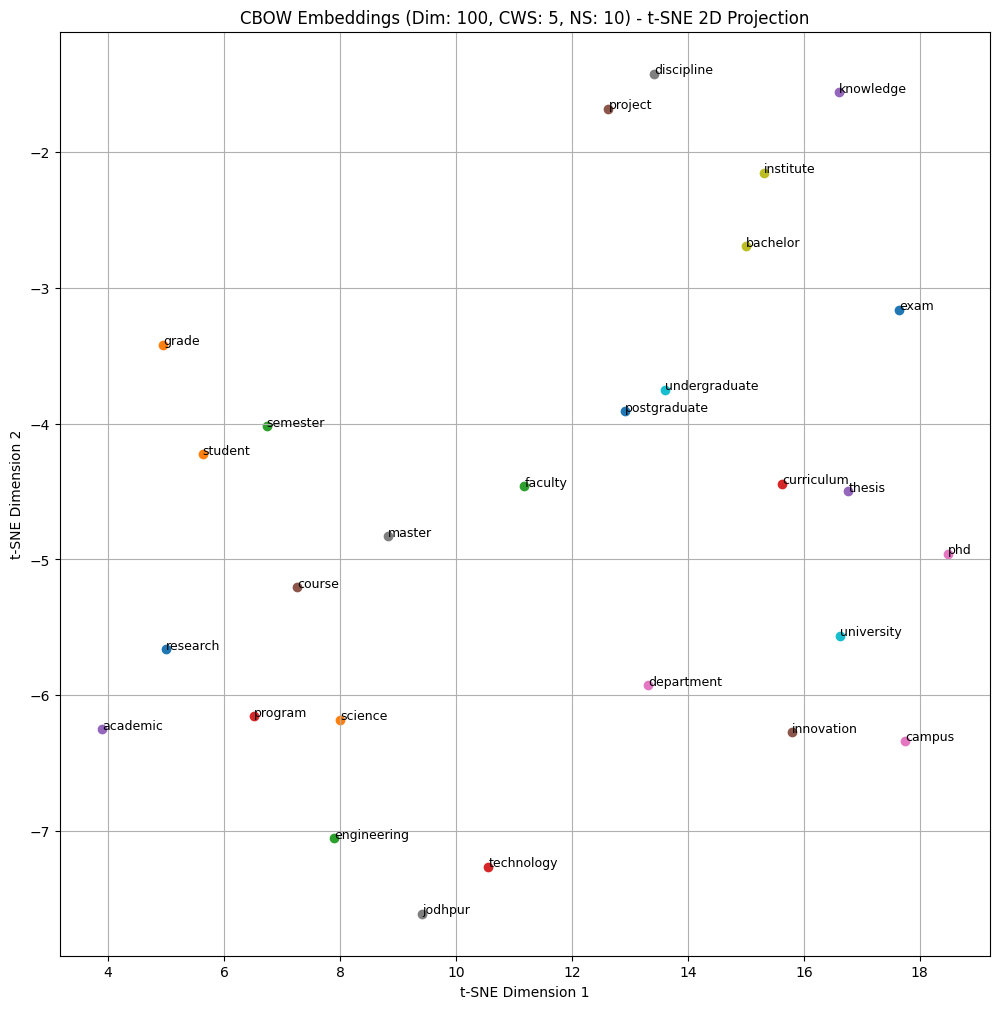

In [ ]:
# Using the CBOW model identified previously
selected_cbow_key = (100, 5, 10)
cbow_W_in_best = cbow_results.get(selected_cbow_key)

if cbow_W_in_best is not None:
    cbow_embeddings_to_visualize = cbow_W_in_best[word_indices]    # Extract embeddings for the selected words
    tsne = TSNE(n_components=2, random_state=42, perplexity=10, n_iter=3000)   # Apply t-SNE
    cbow_tsne_2d = tsne.fit_transform(cbow_embeddings_to_visualize)

    # Plotting
    plt.figure(figsize=(12, 12))
    for i, word in enumerate(valid_words_to_visualize):
        plt.scatter(cbow_tsne_2d[i, 0], cbow_tsne_2d[i, 1])
        plt.annotate(word, (cbow_tsne_2d[i, 0], cbow_tsne_2d[i, 1]), fontsize=9)
    plt.title(f'CBOW Embeddings (Dim: {selected_cbow_key[0]}, CWS: {selected_cbow_key[1]}, NS: {selected_cbow_key[2]}) - t-SNE 2D Projection')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(True)
    plt.show()
else:
    print(f"Error: CBOW model for {selected_cbow_key} not found for visualization.")

### t-SNE Visualization for Skip-gram Model

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


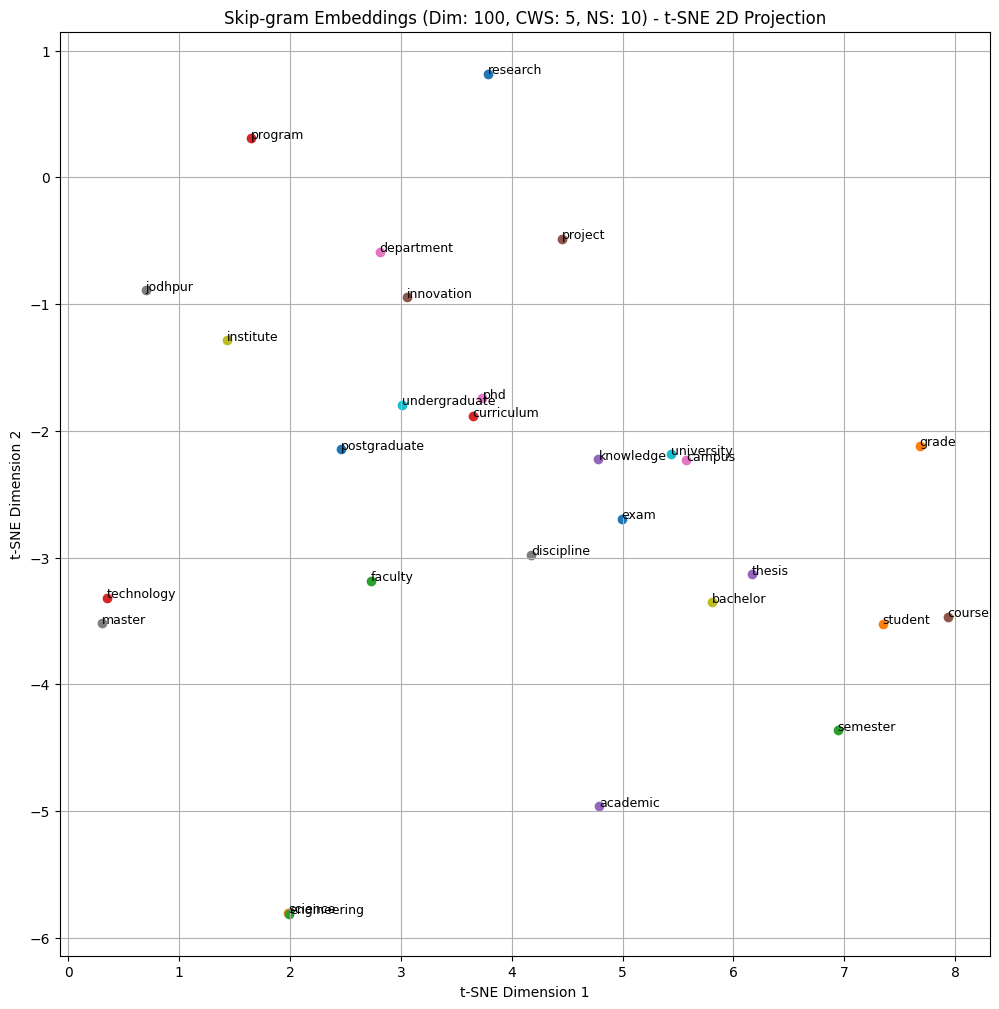

In [ ]:
# Using the Skip-gram model identified previously with same hyper-parameters as CBOW
selected_skipgram_key = (100, 5, 10)
skipgram_W_in_best = skipgram_results.get(selected_skipgram_key)

if skipgram_W_in_best is not None:
    skipgram_embeddings_to_visualize = skipgram_W_in_best[word_indices]    # Extract embeddings for the selected words
    tsne = TSNE(n_components=2, random_state=42, perplexity=10, n_iter=3000)  # Apply t-SNE
    skipgram_tsne_2d = tsne.fit_transform(skipgram_embeddings_to_visualize)

    # Plotting
    plt.figure(figsize=(12, 12))
    for i, word in enumerate(valid_words_to_visualize):
        plt.scatter(skipgram_tsne_2d[i, 0], skipgram_tsne_2d[i, 1])
        plt.annotate(word, (skipgram_tsne_2d[i, 0], skipgram_tsne_2d[i, 1]), fontsize=9)
    plt.title(f'Skip-gram Embeddings (Dim: {selected_skipgram_key[0]}, CWS: {selected_skipgram_key[1]}, NS: {selected_skipgram_key[2]}) - t-SNE 2D Projection')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(True)
    plt.show()
else:
    print(f"Error: Skip-gram model for {selected_skipgram_key} not found for visualization.")